# Task 3

# Эмпирическое распределение и p-value
Цель: промоделировать вычисление порога для заданного уровня значимости.
Задачи:
1. Напишите генератор случайных последовательностей длины L = 9 с частотами генома человека
(A/T : 0.295, G/C : 0.205).
2. Сгенерируйте 100 000 таких "фоновых"последовательностей.
3. Посчитайте скор по вашей PWM для каждой из 100 000 последовательностей.
4. Постройте гистограмму распределения скоров (используя matplotlib.pyplot.hist).
5. Напишите функцию get_pvalue(score), которая возвращает долю фоновых скоров ≥заданного
score.
6. Найдите, какой порог (threshold) нужно установить, чтобы p-value ≈10−4


In [3]:
from Bio import motifs
from Bio.Seq import Seq
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# создание PWM
sites = [
    "GAGGTAAAC",
    "TCCGTAAGC",
    "CAGGTTGGA",
    "ACAGTCAGC",
    "TAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTCGAT",
    "CAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTTGGC"
]
m = motifs.create([Seq(s) for s in sites])
pwm = m.counts.normalize(pseudocounts=0.5).log_odds()

In [6]:
# генерация случайных последовательностей
def generate_random_seq(length=9):
    bases = ['A', 'C', 'G', 'T']
    probs = [0.295, 0.205, 0.205, 0.295]
    return "".join(np.random.choice(bases, p=probs) for _ in range(length))

N = 100000
background_seqs = [generate_random_seq() for _ in range(N)]

In [7]:
# подсчёт скоров
scores = np.array([float(pwm.calculate(Seq(s))) for s in background_seqs])

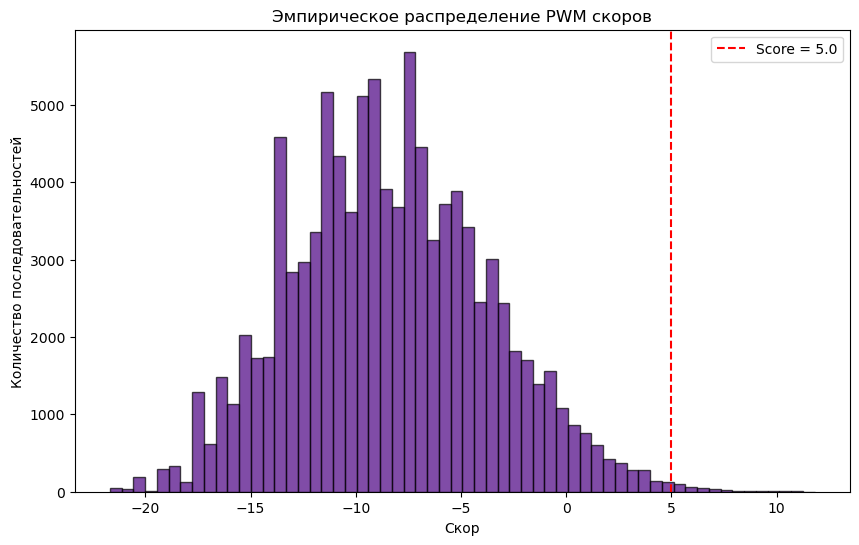

In [10]:
# график
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=60, color='indigo', edgecolor='black', alpha=0.7)
plt.axvline(x=5.0, color='red', linestyle='--', label='Score = 5.0')
plt.title("Эмпирическое распределение PWM скоров")
plt.xlabel("Скор")
plt.ylabel("Количество последовательностей")
plt.legend()
plt.show()

In [9]:
# р-value и порог
def get_pvalue(target_score):
    return np.mean(scores >= target_score)

threshold = np.percentile(scores, 99.99)

print(f"Порог для p-value 10⁻⁴: {threshold:.4f}")
print(f"P-value для скора 5.0:  {get_pvalue(5.0):.6f}")

Порог для p-value 10⁻⁴: 9.6836
P-value для скора 5.0:  0.003550
